# 📊 CEAPS 2021

## Análise Exploratória de Dados (EDA)

**Autor:** Claudio Amaro da Silva

Projeto desenvolvido utilizando Python, Pandas e Plotly para análise dos gastos do CEAPS em 2021.

# 1. Bibliotecas

In [3]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [5]:
import plotly
import importlib.metadata

print("Plotly:", plotly.__version__)
print("Kaleido:", importlib.metadata.version("kaleido"))

Plotly: 6.8.0
Kaleido: 1.3.0


In [7]:
import plotly.io as pio

print(pio.renderers)

Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



# 2. Importação dos Dados

In [10]:
arquivo = r'C:\Users\PC\Documents\DadosCEAPS\ceaps-eda-2021\despesas_ceaps_2021.csv'

df = pd.read_csv(
    arquivo,
    sep=';',
    decimal=',',
    thousands='.'
)

In [12]:
print("="*60)
print("ESTATÍSTICAS")
display(df.describe(include='all'))

ESTATÍSTICAS


,ID,TIPO_DOCUMENTO,ANO,MÊS,COD_SENADOR,NOME_SENADOR,TIPO_DESPESA,CPF_CNPJ_FORNECEDOR,NOME_FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO
count,"16,827.00",16827,"16,827.00","16,827.00","16,827.00",16827,16827,16827,16827,16152,16827,9201,"16,827.00"
unique,NaN,7,NaN,NaN,NaN,86,7,2798,2991,14338,450,5707,NaN
top,NaN,Nota Fiscal Eletrônica,NaN,NaN,NaN,JAQUES WAGNER,"Locomoção, hospedagem, alimentação, combustíve...",16.978.175/0001-08,LATAM,S/N,2021-12-01,DESPESA COM COMBUSTÍVEL EM VEÍCULOS UTILIZADOS...,NaN
freq,NaN,6911,NaN,NaN,NaN,673,5754,1181,464,50,130,481,NaN
mean,"2,164,206.68",NaN,"2,021.00",6.91,"4,185.45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,486.92"
std,"5,513.37",NaN,0.00,3.30,"2,201.15",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,955.99"
min,"2,154,172.00",NaN,"2,021.00",1.00,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01
25%,"2,159,606.50",NaN,"2,021.00",4.00,"1,186.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,188.12
50%,"2,164,208.00",NaN,"2,021.00",7.00,"5,411.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.00
75%,"2,168,818.50",NaN,"2,021.00",10.00,"5,894.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,673.25"


In [14]:
total_gasto = df['VALOR_REEMBOLSADO'].sum()

media_gasto = df['VALOR_REEMBOLSADO'].mean()

total_senadores = df['NOME_SENADOR'].nunique()

total_fornecedores = df['NOME_FORNECEDOR'].nunique()

print(f'Total gasto: R$ {total_gasto:,.2f}')
print(f'Média por lançamento: R$ {media_gasto:,.2f}')
print(f'Senadores: {total_senadores}')
print(f'Fornecedores: {total_fornecedores}')

Total gasto: R$ 25,020,323.84
Média por lançamento: R$ 1,486.92
Senadores: 86
Fornecedores: 2991


# 3. Criação dos DataFrames

In [17]:
# ==============================
# Categorias
# ==============================

despesas_categoria = (
    df.groupby('TIPO_DESPESA', as_index=False)
      .agg(
          TOTAL=('VALOR_REEMBOLSADO','sum'),
          MEDIA=('VALOR_REEMBOLSADO','mean'),
          QUANTIDADE=('VALOR_REEMBOLSADO','count')
      )
      .sort_values('TOTAL', ascending=False)
)

despesas_categoria['PERCENTUAL'] = (
    despesas_categoria['TOTAL']
    / despesas_categoria['TOTAL'].sum()
    *100
).round(2)


# ==============================
# Top Senadores
# ==============================

top_senadores = (
    df.groupby('NOME_SENADOR', as_index=False)
      .agg(
          TOTAL=('VALOR_REEMBOLSADO','sum'),
          MEDIA=('VALOR_REEMBOLSADO','mean'),
          QUANTIDADE=('VALOR_REEMBOLSADO','count')
      )
      .sort_values('TOTAL', ascending=False)
      .head(10)
)


# ==============================
# Top Fornecedores
# ==============================

top_fornecedores = (
    df.groupby('NOME_FORNECEDOR', as_index=False)
      .agg(
          TOTAL=('VALOR_REEMBOLSADO','sum'),
          MEDIA=('VALOR_REEMBOLSADO','mean'),
          QUANTIDADE=('VALOR_REEMBOLSADO','count')
      )
      .sort_values('TOTAL', ascending=False)
      .head(10)
)


# ==============================
# Gastos Mensais
# ==============================

gastos_mes = (
    df.groupby('MÊS', as_index=False)
      .agg(
          TOTAL=('VALOR_REEMBOLSADO', 'sum')
      )
)

nomes = {
1:'Jan',
2:'Fev',
3:'Mar',
4:'Abr',
5:'Mai',
6:'Jun',
7:'Jul',
8:'Ago',
9:'Set',
10:'Out',
11:'Nov',
12:'Dez'
}

gastos_mes['MES_NOME'] = gastos_mes['MÊS'].map(nomes)


# ==============================
# Heatmap
# ==============================

heatmap = df.pivot_table(
    values='VALOR_REEMBOLSADO',
    index='TIPO_DESPESA',
    columns='MÊS',
    aggfunc='sum'
)

print("DataFrames para próximas análises criados com sucesso!")

DataFrames para próximas análises criados com sucesso!


# 4. Geração dos Gráficos

In [20]:
import plotly.graph_objects as go

# =====================================================
# 1. Gastos por Categoria
# =====================================================

fig_categoria = go.Figure()

fig_categoria.add_trace(
    go.Bar(
        x=despesas_categoria['TIPO_DESPESA'],
        y=despesas_categoria['TOTAL']
    )
)

fig_categoria.update_layout(
    title='Gastos por Categoria',
    template='plotly_white'
)

# =====================================================
# 2. Top 10 Senadores
# =====================================================

fig_senadores = go.Figure()

fig_senadores.add_trace(
    go.Bar(
        x=top_senadores['NOME_SENADOR'],
        y=top_senadores['TOTAL']
    )
)

fig_senadores.update_layout(
    title='Top 10 Senadores',
    template='plotly_white'
)

# =====================================================
# 3. Top 10 Fornecedores
# =====================================================

fig_fornecedores = go.Figure()

fig_fornecedores.add_trace(
    go.Bar(
        x=top_fornecedores['NOME_FORNECEDOR'],
        y=top_fornecedores['TOTAL']
    )
)

fig_fornecedores.update_layout(
    title='Top 10 Fornecedores',
    template='plotly_white'
)

# =====================================================
# 4. Evolução Mensal
# =====================================================

fig_mes = go.Figure()

fig_mes.add_trace(
    go.Scatter(
        x=gastos_mes['MES_NOME'],
        y=gastos_mes['TOTAL'],
        mode='lines+markers'
    )
)

fig_mes.update_layout(
    title='Evolução Mensal',
    template='plotly_white'
)

# =====================================================
# 5. Heatmap
# =====================================================

fig_heatmap = go.Figure()

fig_heatmap.add_trace(
    go.Heatmap(
        z=heatmap.values,
        x=heatmap.columns,
        y=heatmap.index
    )
)

fig_heatmap.update_layout(
    title='Heatmap de Gastos',
    template='plotly_white'
)

print("Pipeline de gráficos criados com sucesso.")

Pipeline de gráficos criados com sucesso.


# 5. Dashboard Integrado

Demonstrativo dos gráficos serão mostrados abaixo sem formatação visual


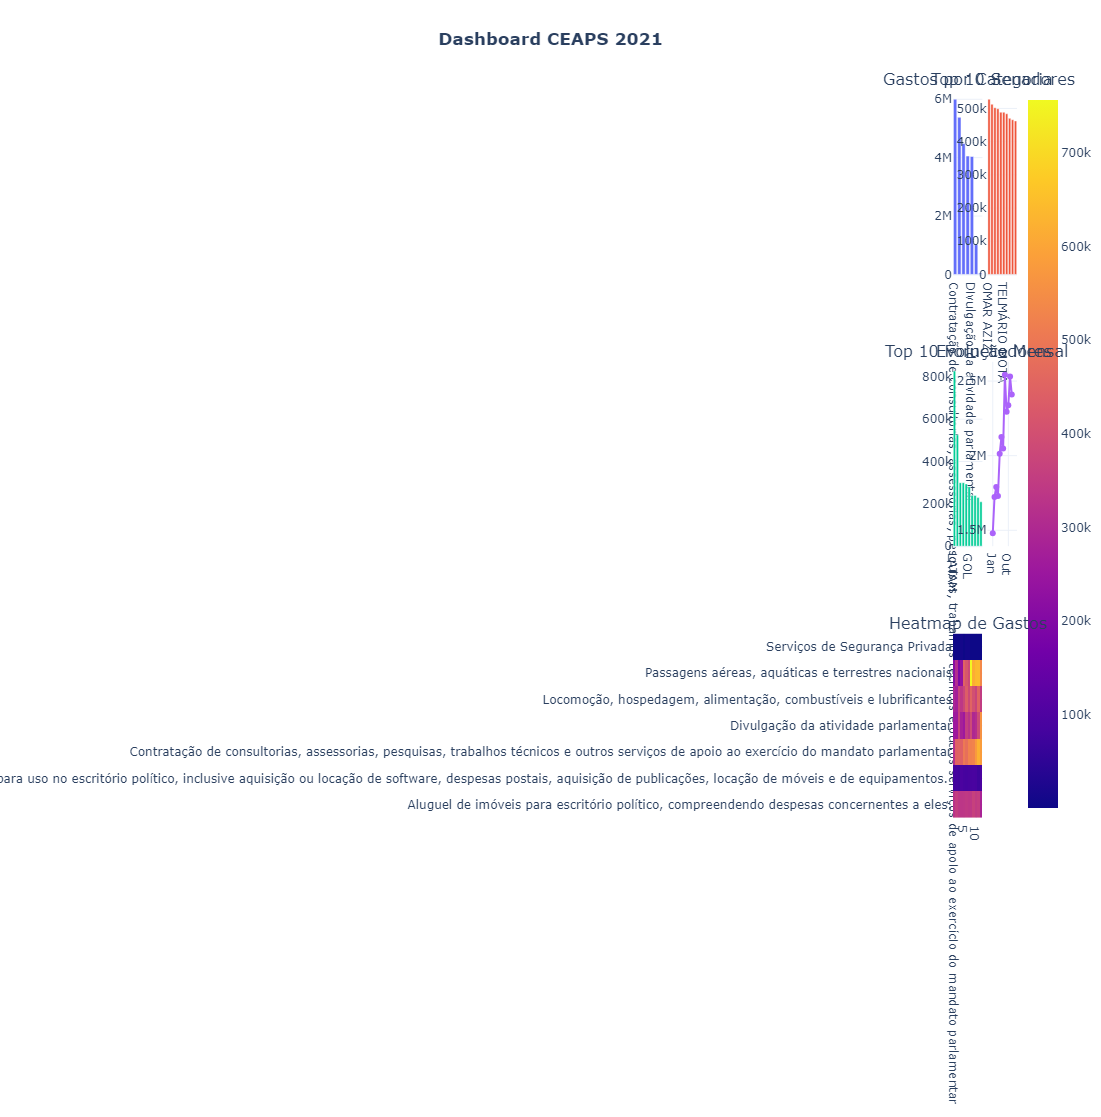

In [23]:
from plotly.subplots import make_subplots

# =====================================================
# DASHBOARD
# =====================================================

dashboard = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=(
        "Gastos por Categoria",
        "Top 10 Senadores",
        "Top 10 Fornecedores",
        "Evolução Mensal",
        "Heatmap de Gastos",
        ""
    ),
    specs=[
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "scatter"}],
        [{"type": "heatmap"}, None]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# =====================================================
# Categoria
# =====================================================

dashboard.add_trace(
    fig_categoria.data[0],
    row=1,
    col=1
)

# =====================================================
# Senadores
# =====================================================

dashboard.add_trace(
    fig_senadores.data[0],
    row=1,
    col=2
)

# =====================================================
# Fornecedores
# =====================================================

dashboard.add_trace(
    fig_fornecedores.data[0],
    row=2,
    col=1
)

# =====================================================
# Evolução Mensal
# =====================================================

dashboard.add_trace(
    fig_mes.data[0],
    row=2,
    col=2
)

# =====================================================
# Heatmap
# =====================================================

dashboard.add_trace(
    fig_heatmap.data[0],
    row=3,
    col=1
)

# =====================================================
# Layout Geral
# =====================================================

dashboard.update_layout(

    title={
        "text":"<b>Dashboard CEAPS 2021</b>",
        "x":0.5
    },

    template="plotly_white",

    height=1100,
    width=1500,

    showlegend=False,

    margin=dict(
        l=40,
        r=40,
        t=90,
        b=40
    )
)

print("Demonstrativo dos gráficos serão mostrados abaixo sem formatação visual")

dashboard.show()

# 6. KPIs

In [26]:
# =====================================================
# KPIs EXECUTIVOS
# =====================================================

kpis = pd.DataFrame({
    "Indicador": [
        "💰 Total Reembolsado",
        "📄 Quantidade de Despesas",
        "👤 Senadores",
        "🏢 Fornecedores",
        "📊 Ticket Médio",
        "🥇 Maior Categoria",
        "🏛️ Maior Senador",
        "✈️ Maior Fornecedor"
    ],
    "Valor": [
        f"R$ {df['VALOR_REEMBOLSADO'].sum():,.2f}",
        f"{len(df):,}",
        df['NOME_SENADOR'].nunique(),
        df['NOME_FORNECEDOR'].nunique(),
        f"R$ {df['VALOR_REEMBOLSADO'].mean():,.2f}",
        despesas_categoria.iloc[0]['TIPO_DESPESA'],
        top_senadores.iloc[0]['NOME_SENADOR'],
        top_fornecedores.iloc[0]['NOME_FORNECEDOR']
    ]
})

display(kpis)

,Indicador,Valor
0,💰 Total Reembolsado,"R$ 25,020,323.84"
1,📄 Quantidade de Despesas,"16,827"
2,👤 Senadores,86
3,🏢 Fornecedores,2991
4,📊 Ticket Médio,"R$ 1,486.92"
5,🥇 Maior Categoria,"Contratação de consultorias, assessorias, pesq..."
6,🏛️ Maior Senador,OMAR AZIZ
7,✈️ Maior Fornecedor,LATAM


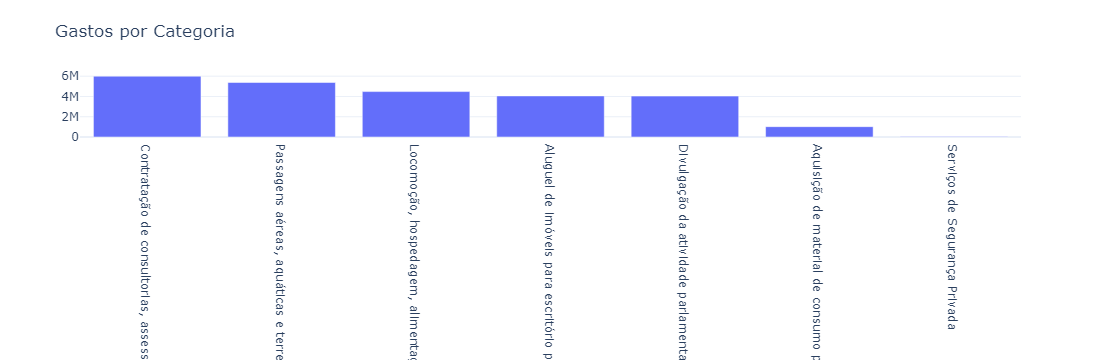

In [28]:
fig_categoria.show()

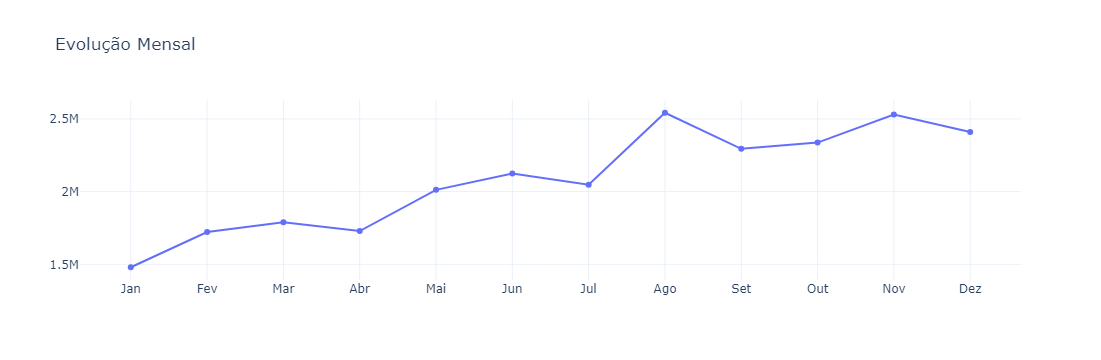

In [30]:
fig_mes.show()

# CEAPS 2021 - Análise Exploratória dos Gastos

## Página 1 - Visão Executiva

## Análise Executiva

A análise dos gastos do CEAPS em 2021 evidencia uma concentração significativa dos recursos em poucas categorias de despesas. As despesas com consultorias representam aproximadamente **24%** do total reembolsado, seguidas por gastos com passagens e despesas de locomoção, hospedagem e combustíveis.

Em conjunto, essas categorias concentram a maior parte dos recursos reembolsados, demonstrando que o orçamento do CEAPS está fortemente direcionado às atividades essenciais de suporte ao exercício da atividade parlamentar.

O valor médio por solicitação de reembolso foi de aproximadamente **R$ 1.487**, embora exista grande variação entre os valores individuais, refletindo a diversidade dos tipos de despesas analisadas.

A distribuição mensal dos reembolsos permite observar o comportamento dos gastos ao longo do ano e poderá servir de base para análises de sazonalidade e identificação de padrões temporais.porais.porais.

## Principais Achados

- Total reembolsado:aproximadamente **R$ 25 milhões**.
 
- Quantidade de despesas analisadas: **16.827** registros.
  
- Senadores analisados: **86**.
 
- Total de fornecedores: **2.991**.
 
- Categoria com maior participação: **Contratação de Consultorias** (23,98% do total).
 
- Cinco categorias concentram mais de **95%** dos recursos reembolsados.
 
- Valor médio por reembolso: aproximadamente **R$ 1.487**.

#  Página 2 - Análise dos Senadores

## Objetivo

Analisar a distribuição dos reembolsos entre os senadores, identificando aqueles que concentraram maiores valores, a frequência das solicitações e possíveis padrões na utilização do CEAPS.

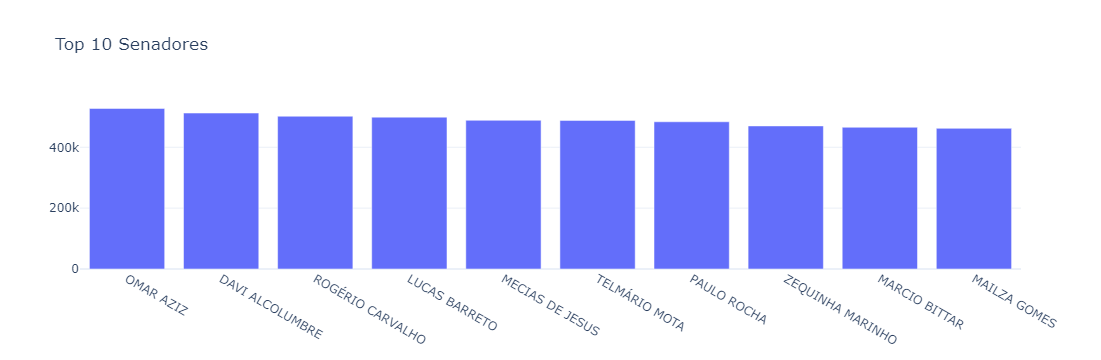

In [37]:
fig_senadores.show()

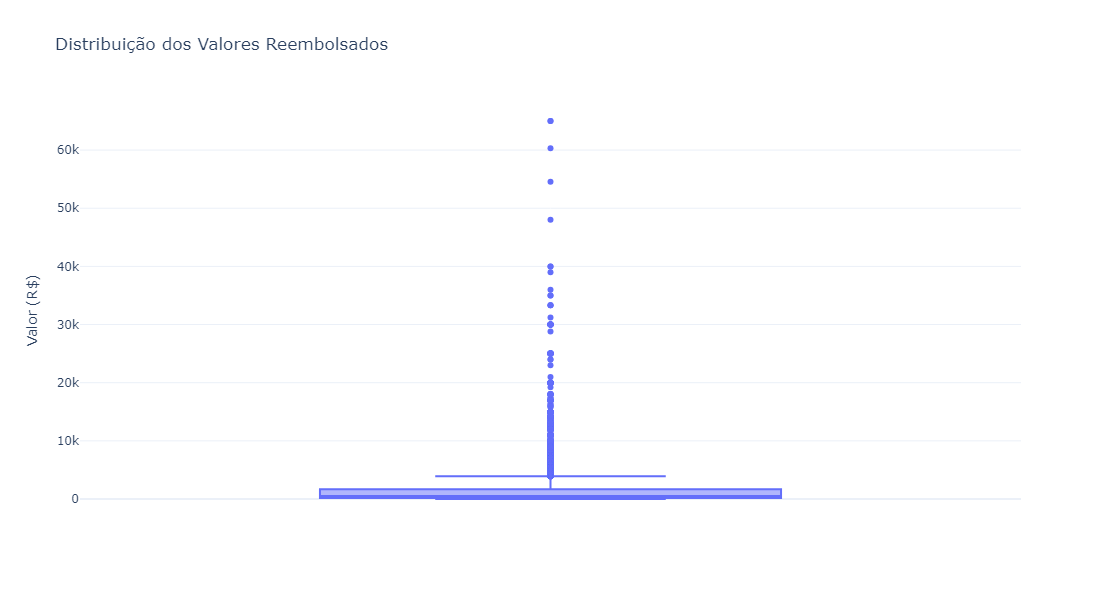

In [39]:
import plotly.express as px

fig_box = px.box(
    df,
    y='VALOR_REEMBOLSADO',
    points='outliers',
    title='Distribuição dos Valores Reembolsados'
)

fig_box.update_layout(
    template='plotly_white',
    height=600,
    width=900,
    yaxis_title='Valor (R$)'
)

fig_box.show()

## Análise Executiva

Os valores reembolsados apresentam distribuição heterogênea entre os senadores. Embora exista um grupo com maiores volumes de reembolso, observa-se que a participação individual permanece relativamente baixa em relação ao total executado, indicando que os recursos estão distribuídos entre os 86 parlamentares analisados.

O boxplot evidencia elevada dispersão dos valores das solicitações individuais, além da presença de valores extremos (outliers), característica esperada em bases financeiras que contemplam diferentes naturezas de despesas.

A análise também demonstra que o maior volume financeiro não está necessariamente associado ao maior número de solicitações, indicando perfis distintos de utilização da verba parlamentar.

## Principais Achados

- Foram analisados reembolsos de **86 senadores**.
- Os dez maiores reembolsos representam aproximadamente **20%** do total desembolsado.
- Existe elevada dispersão nos valores individuais dos reembolsos.
- Foram identificados valores extremos (outliers), compatíveis com despesas de maior porte.
- A frequência de solicitações varia significativamente entre os parlamentares.

# Página 3 - Análise dos Fornecedores

## Objetivo

Analisar a distribuição dos pagamentos entre os fornecedores, identificando aqueles que receberam os maiores valores, o nível de concentração dos recursos e possíveis padrões na execução das despesas.

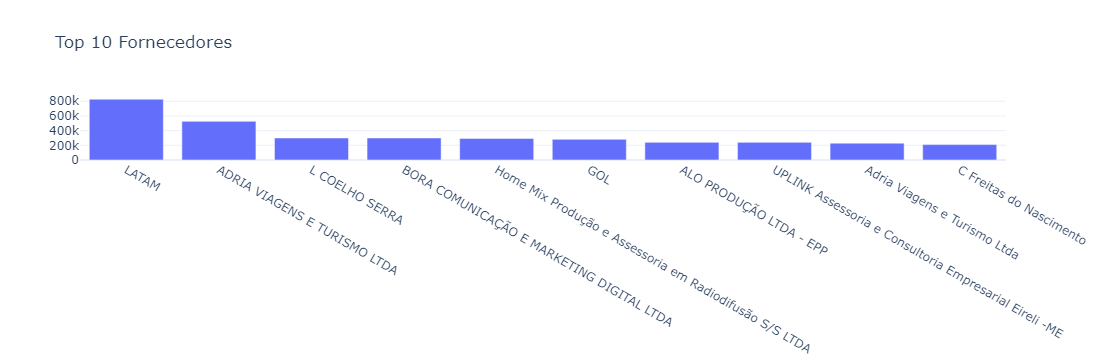

In [44]:
fig_fornecedores.show()

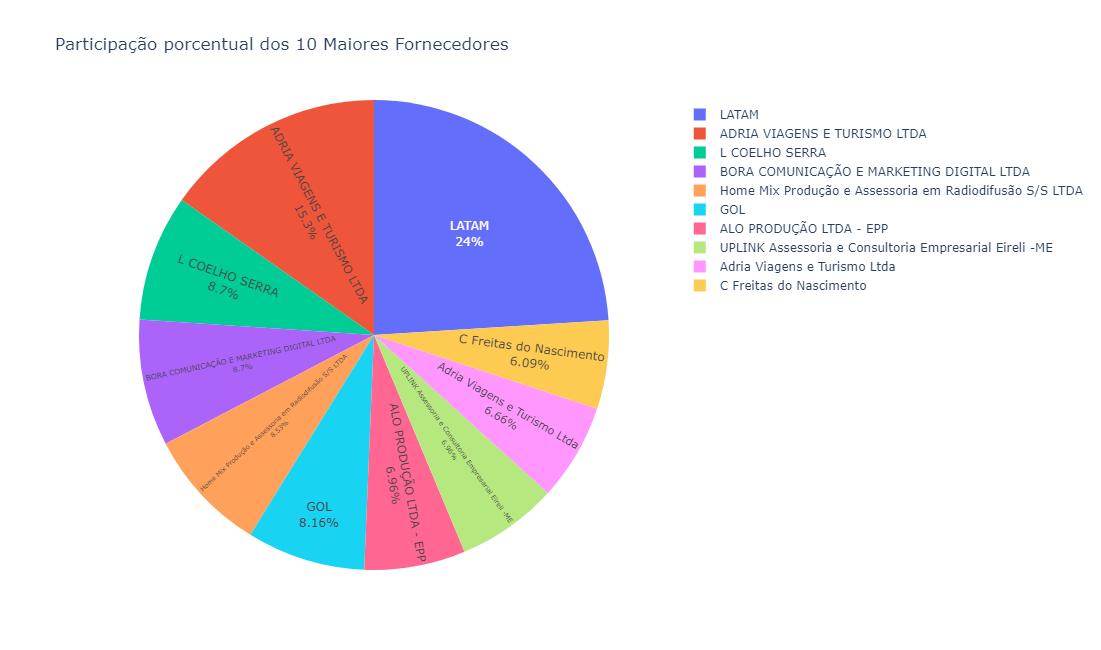

In [46]:
import plotly.express as px

fig_top10 = px.pie(
    top_fornecedores,
    names='NOME_FORNECEDOR',
    values='TOTAL',
    title='Participação porcentual dos 10 Maiores Fornecedores'
)

fig_top10.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig_top10.update_layout(
    template='plotly_white',
    height=650,
    width=900
)

fig_top10.show()

## Análise Executiva

Os pagamentos do CEAPS foram realizados para **2.991 fornecedores distintos**, demonstrando uma elevada diversidade de prestadores de serviços e empresas.

A LATAM aparece como o fornecedor com maior volume financeiro, refletindo a importância das despesas com transporte aéreo para o exercício da atividade parlamentar.

Observa-se também que poucos fornecedores concentram parcelas relevantes dos pagamentos, enquanto a grande maioria recebe valores reduzidos, caracterizando uma distribuição assimétrica típica de bases financeiras dessa natureza.

Essa concentração está associada principalmente às categorias de passagens, consultorias e comunicação institucional.

## Principais Achados

- Foram identificados **2.991 fornecedores** distintos.
- A **LATAM** foi o fornecedor que recebeu o maior volume de recursos em 2021.
- Os pagamentos apresentam **elevada pulverização** entre fornecedores.
- **Poucos fornecedores** concentram **parte significativa** dos recursos.
- A **distribuição dos pagamentos** está diretamente relacionada às **principais categorias** de despesas do CEAPS.

# Página 4 - Conclusões Gerais e Recomendações

## Conclusões Gerais

A análise exploratória dos dados do CEAPS referentes ao ano de 2021 permitiu compreender a estrutura dos reembolsos realizados aos senadores brasileiros e identificar padrões relevantes de utilização dos recursos.

Os resultados demonstraram que aproximadamente **R$ 25 milhões** foram reembolsados em **16.827 solicitações**, distribuídas entre **86 senadores** e **2.991 fornecedores**.

Observou-se elevada concentração dos gastos em poucas categorias de despesas. As categorias de **Consultorias**, **Passagens** e **Locomoção/Hospedagem/Combustíveis** responderam pela maior parcela do orçamento executado, evidenciando sua importância para o desempenho das atividades parlamentares.

Também foi identificada uma distribuição heterogênea entre senadores e fornecedores. Embora exista concentração dos maiores valores em alguns casos, a maior parte dos recursos encontra-se distribuída entre diversos participantes, característica comum em bases de despesas públicas.

A análise temporal demonstrou que os reembolsos ocorreram ao longo de todo o ano de 2021, possibilitando futuras investigações sobre sazonalidade, comportamento mensal das despesas e padrões de utilização da verba parlamentar.

## Limitações da Análise

Este estudo possui caráter exploratório e foi desenvolvido exclusivamente com os dados disponibilizados pelo Senado Federal referentes ao exercício de 2021.

Alguns aspectos não foram considerados nesta etapa, como:

- comparação com outros anos;
- análise por unidade da federação;
- comparação entre partidos políticos;
- avaliação da conformidade das despesas;
- análise detalhada por fornecedor ou documento fiscal.

Esses temas representam oportunidades para futuras investigações.

## Possíveis Trabalhos Futuros

Como continuidade deste projeto, podem ser desenvolvidas novas análises, entre elas:

- Comparação dos gastos entre diferentes anos do CEAPS;
- Identificação de tendências temporais e sazonalidade;
- Análise por partido político e estado;
- Construção de modelos preditivos para estimativa de despesas;
- Detecção de padrões atípicos utilizando técnicas de Machine Learning;
- Desenvolvimento de dashboards interativos em Power BI e Dash;
- Automatização da atualização dos dados por meio de pipelines em Python.

# Tecnologias Utilizadas

- Python
- Pandas
- NumPy
- Plotly
- Jupyter Notebook

# Competências Demonstradas

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- KPI Development
- Business Intelligence
- Storytelling com Dados

In [55]:
!jupyter nbconvert --to html "Análise_CEAPS_2021.ipynb"

[NbConvertApp] Converting notebook Análise_CEAPS_2021.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 1414526 bytes to Análise_CEAPS_2021.html


# Funções de Visualização

In [58]:
import plotly.graph_objects as go


COR_PRINCIPAL = "#1f77b4"


def aplicar_layout(fig, titulo, eixo_x="", eixo_y=""):

    fig.update_layout(

        template="plotly_white",

        title=dict(
            text=titulo,
            x=0.5,
            font=dict(size=22)
        ),

        width=1200,
        height=650,

        font=dict(
            family="Arial",
            size=13
        ),

        margin=dict(
            l=70,
            r=40,
            t=80,
            b=70
        ),

        xaxis_title=eixo_x,

        yaxis_title=eixo_y,

        showlegend=False
    )

    fig.update_xaxes(
        showgrid=False
    )

    fig.update_yaxes(
        showgrid=True,
        gridcolor="lightgray"
    )

    return fig

In [60]:
def grafico_categoria(df):

    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=df['TIPO_DESPESA'],
            y=df['TOTAL'],
            marker_color=COR_PRINCIPAL,
            text=df['PERCENTUAL'].round(1).astype(str) + "%",
            textposition='outside'
        )
    )

    fig = aplicar_layout(
        fig,
        titulo="Total Reembolsado por Categoria",
        eixo_x="Categoria",
        eixo_y="Valor Reembolsado (R$)"
    )

    fig.update_yaxes(tickprefix="R$ ")

    return fig

# Geração dos Gráficos

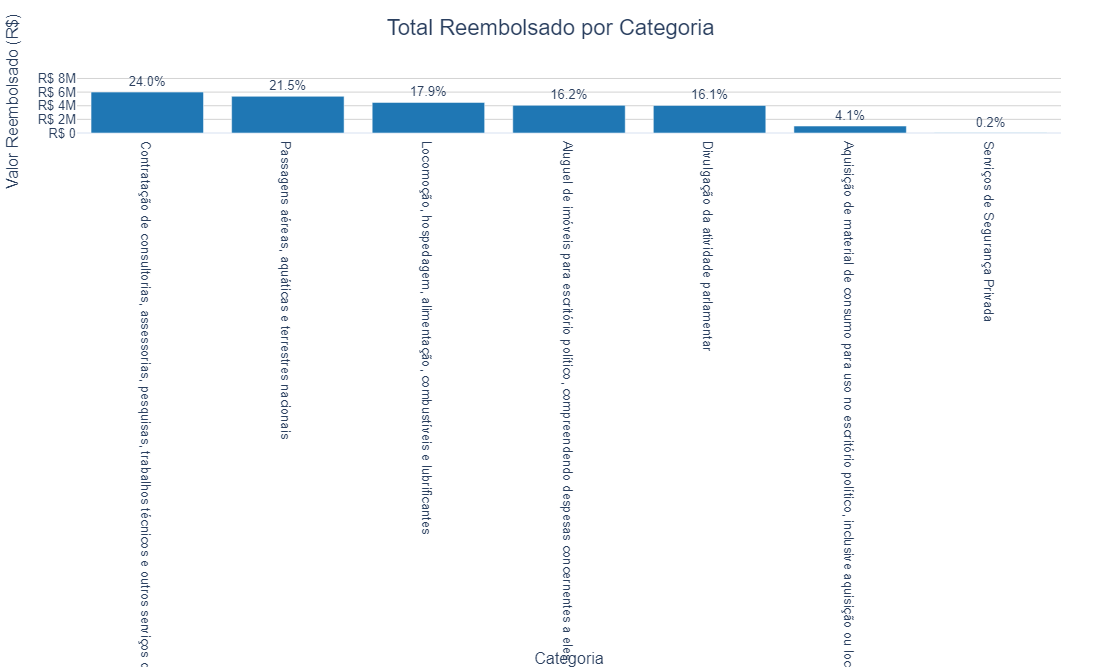

In [63]:
fig_categoria = grafico_categoria(despesas_categoria)

fig_categoria.show()

In [65]:
print(type(despesas_categoria))

<class 'pandas.core.frame.DataFrame'>


In [67]:
def grafico_senadores(df):

    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=df['NOME_SENADOR'],
            y=df['TOTAL'],
            marker_color=COR_PRINCIPAL,
            text=df['TOTAL'].apply(lambda x: f'R$ {x:,.0f}'.replace(',', '.')),
            textposition='outside'
        )
    )

    fig = aplicar_layout(
        fig,
        titulo="Top 10 Senadores por Valor Reembolsado",
        eixo_x="Senador",
        eixo_y="Valor Reembolsado (R$)"
    )

    fig.update_xaxes(tickangle=-30)
    fig.update_yaxes(tickprefix="R$ ")

    return fig

In [69]:
def grafico_fornecedores(df):

    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=df['NOME_FORNECEDOR'],
            y=df['TOTAL'],
            marker_color=COR_PRINCIPAL,
            text=df['TOTAL'].apply(lambda x: f'R$ {x:,.0f}'.replace(',', '.')),
            textposition='outside'
        )
    )

    fig = aplicar_layout(
        fig,
        titulo="Top 10 Fornecedores por Valor Reembolsado",
        eixo_x="Fornecedor",
        eixo_y="Valor Reembolsado (R$)"
    )

    fig.update_xaxes(tickangle=-35)
    fig.update_yaxes(tickprefix="R$ ")

    return fig

In [71]:
def grafico_mensal(df):

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df['MES_NOME'],
            y=df['TOTAL'],
            mode='lines+markers+text',
            text=[f'R$ {v:,.0f}'.replace(',', '.') for v in df['TOTAL']],
            textposition='top center',
            line=dict(width=3, color=COR_PRINCIPAL),
            marker=dict(size=9)
        )
    )

    fig = aplicar_layout(
        fig,
        titulo="Evolução Mensal dos Reembolsos",
        eixo_x="Mês",
        eixo_y="Valor Reembolsado (R$)"
    )

    fig.update_yaxes(tickprefix="R$ ")

    return fig

In [73]:
def grafico_heatmap(df):

    # Abreviações das categorias
    categorias = {
        'Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.':
            'Alug. Imóveis',

        'Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.':
            'Mat. Escrit.',

        'Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar':
            'Consultorias',

        'Divulgação da atividade parlamentar':
            'Divulgação',

        'Locomoção, hospedagem, alimentação, combustíveis e lubrificantes':
            'Loc./Hosp.',

        'Passagens aéreas, aquáticas e terrestres nacionais':
            'Passagens',

        'Serviços de Segurança Privada':
            'Segurança'
    }

    y = [categorias.get(c, c[:20]) for c in df.index]

    fig = go.Figure(
        data=go.Heatmap(
            z=df.values,
            x=df.columns,
            y=y,

            colorscale='Blues',

            colorbar=dict(
                title='R$',
                thickness=18,
                len=0.70
            )
        )
    )

    fig.update_layout(

        template='plotly_white',

        title=dict(
            text='Distribuição Mensal dos Gastos por Categoria',
            x=0.5,
            font=dict(size=22)
        ),

        width=1300,
        height=700,

        margin=dict(
            l=220,
            r=50,
            t=80,
            b=70
        ),

        xaxis_title='Mês',
        yaxis_title='Categoria',

        font=dict(
            family='Arial',
            size=13
        )
    )

    return fig

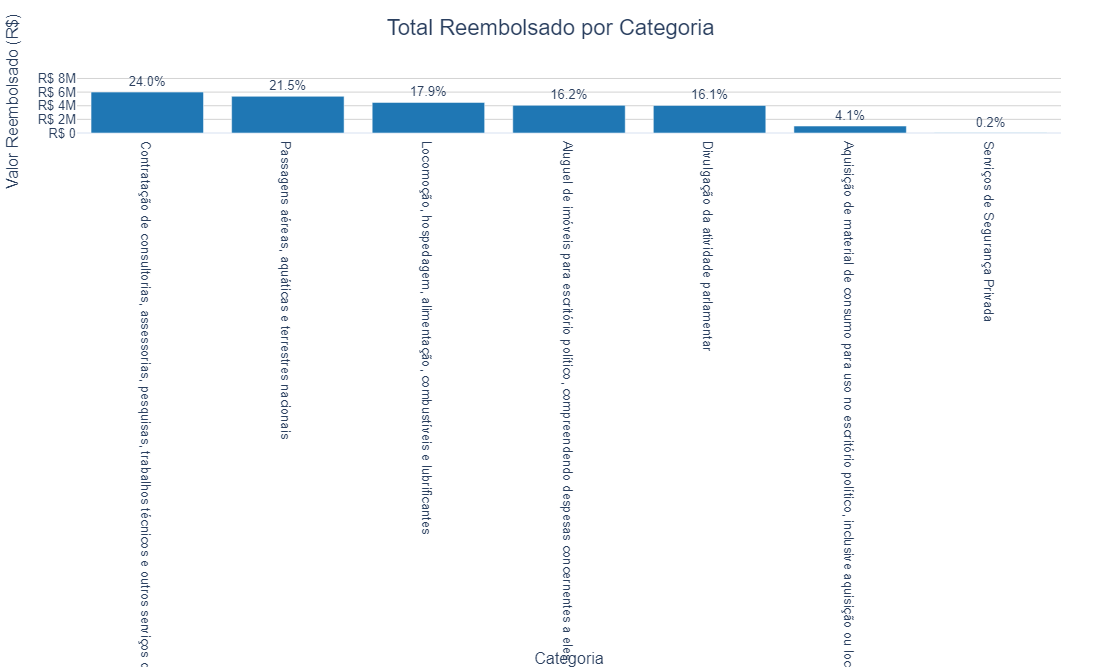

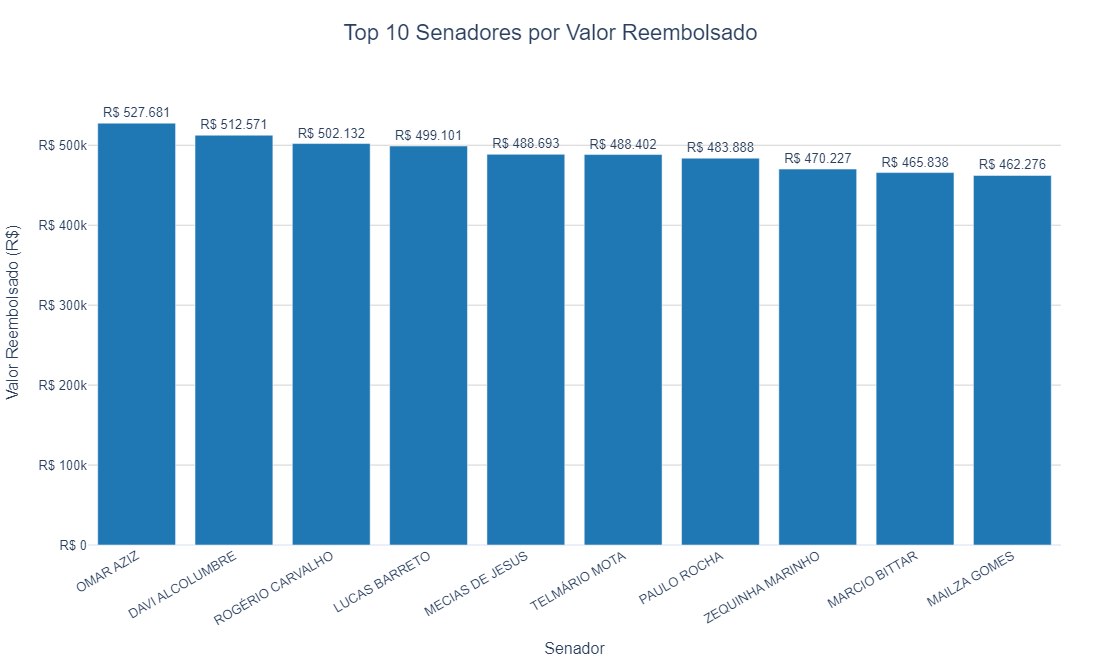

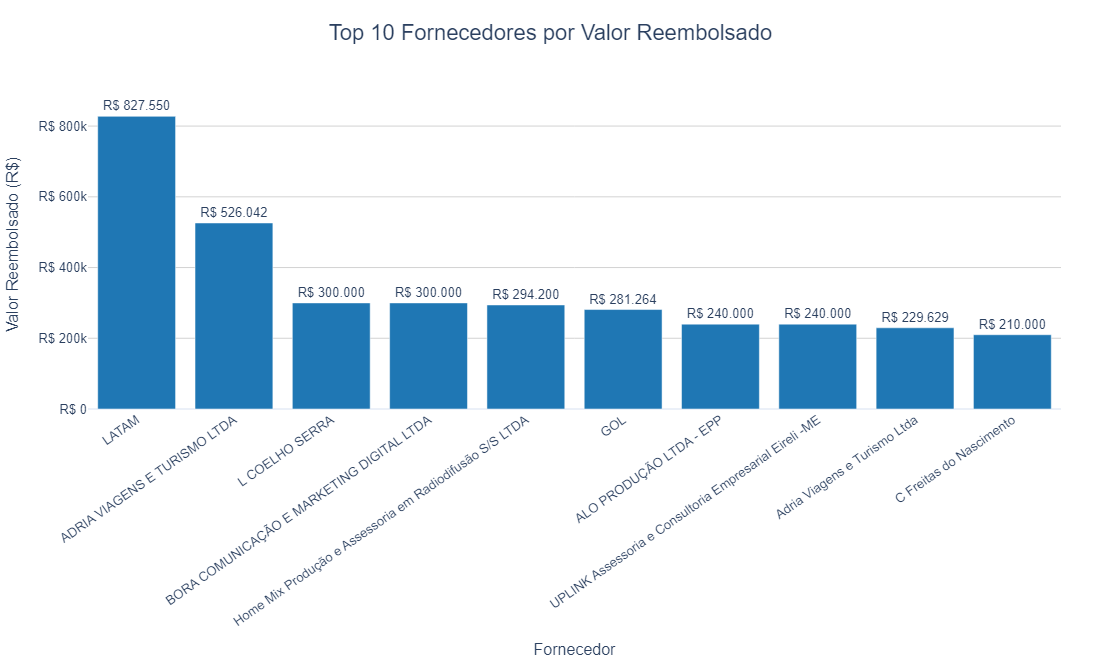

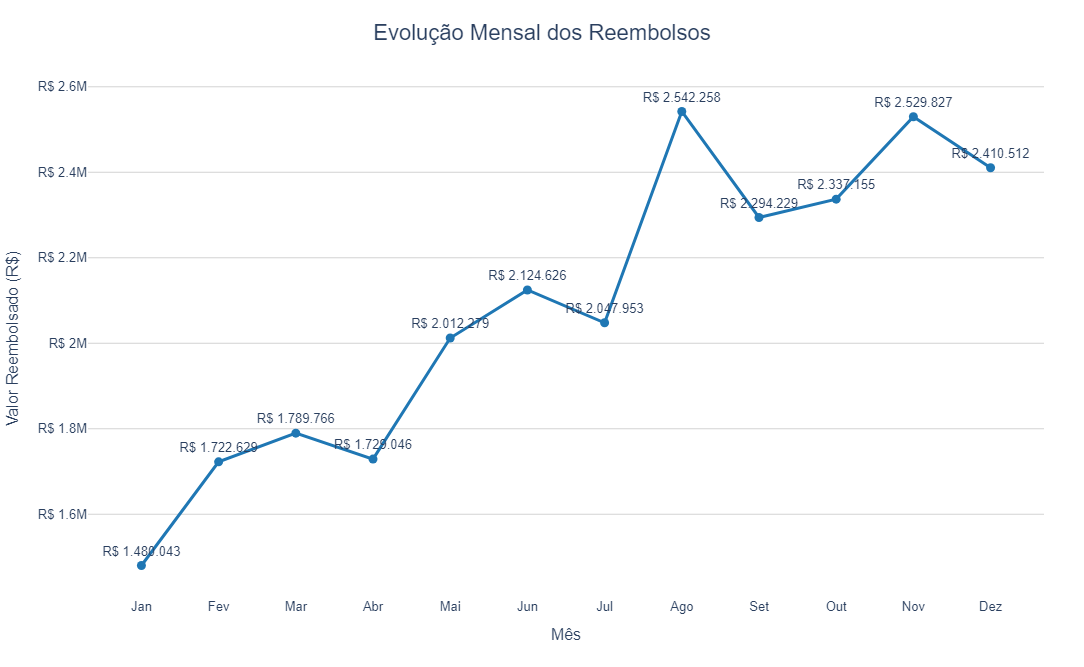

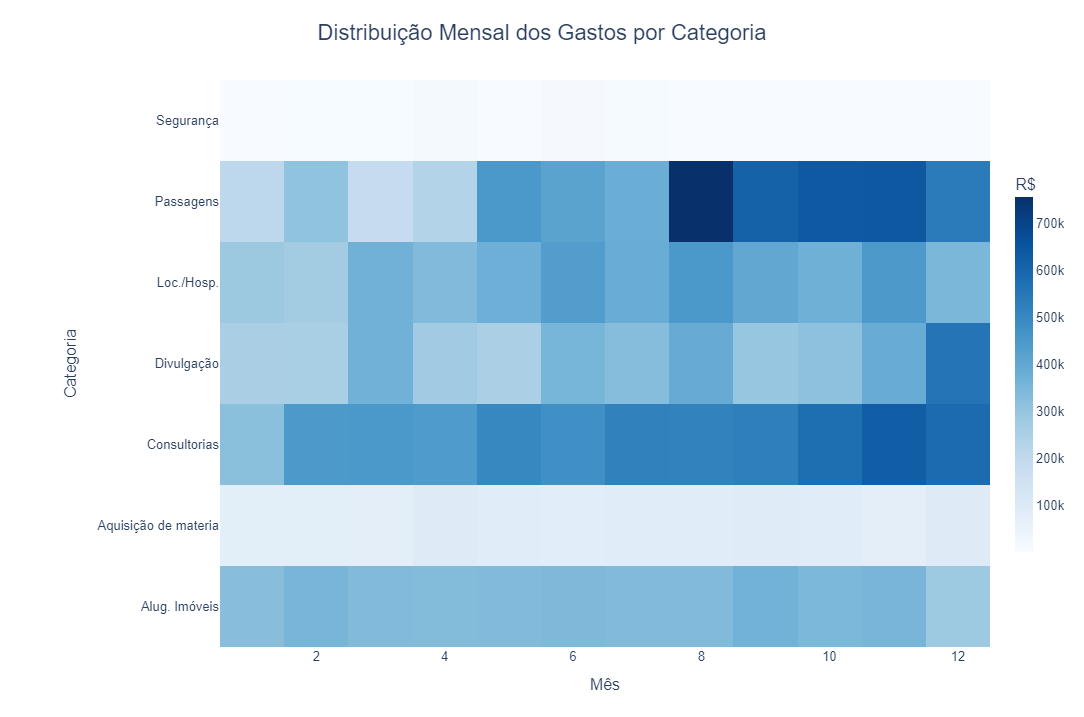

In [75]:
fig_categoria = grafico_categoria(despesas_categoria)
fig_senadores = grafico_senadores(top_senadores)
fig_fornecedores = grafico_fornecedores(top_fornecedores)
fig_mensal = grafico_mensal(gastos_mes)
fig_heatmap = grafico_heatmap(heatmap)

fig_categoria.show()
fig_senadores.show()
fig_fornecedores.show()
fig_mensal.show()
fig_heatmap.show()

In [115]:
!pip install kaleido

   ---------------------------------------- 0.0/55.6 kB ? eta -:--:--
   ------------------------------------ --- 51.2/55.6 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 55.6/55.6 kB 581.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/52.6 kB ? eta -:--:--
   -------------------------------------- - 51.2/52.6 kB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 52.6/52.6 kB 543.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/90.7 kB ? eta -:--:--
   ------------------------------------ --- 81.9/90.7 kB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 90.7/90.7 kB 1.0 MB/s eta 0:00:00
  Attempting uninstall: platformdirs
    Found existing installation: platformdirs 3.10.0
    Uninstalling platformdirs-3.10.0:
      Successfully uninstalled platformdirs-3.10.0


In [121]:
!pip install -U kaleido

In [77]:
!pip install --upgrade kaleido

In [79]:
import os

os.makedirs("images", exist_ok=True)

In [81]:
fig_categoria.write_image(
    "images/categorias.png",
    width=1600,
    height=900,
    scale=2
)

fig_senadores.write_image(
    "images/senadores.png",
    width=1600,
    height=900,
    scale=2
)

fig_fornecedores.write_image(
    "images/fornecedores.png",
    width=1600,
    height=900,
    scale=2
)

fig_mensal.write_image(
    "images/mensal.png",
    width=1600,
    height=900,
    scale=2
)

fig_heatmap.write_image(
    "images/heatmap.png",
    width=1600,
    height=900,
    scale=2
)

print("Gráficos exportados com sucesso!")

Gráficos exportados com sucesso!
